# CLASSIFICATION

# Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor

from sklearn.ensemble import AdaBoostClassifier,AdaBoostRegressor

from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score,roc_auc_score,roc_curve,confusion_matrix,ConfusionMatrixDisplay

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [2]:
df = pd.read_csv("clean_data.csv")

df.head()

,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,32.0,3,0,2,2,0,12.0,1.0,7.6,1.0,6.0,1.0,1.0,53.3,0.655,0.0,49.8
1,17.0,3,0,2,2,4,34.0,16.0,27.2,6.0,4.0,7.0,1.0,51.5,1.000,1.0,84.0
2,25.0,3,1,0,0,4,39.0,6.0,7.1,16.0,2.0,2.0,0.0,62.2,0.810,0.0,62.5
3,26.0,2,1,2,1,2,10.0,34.0,22.1,57.0,9.0,6.0,0.0,59.3,0.875,1.0,89.5
4,26.0,2,2,3,0,0,12.0,22.0,32.3,41.0,9.0,2.0,0.0,65.1,0.814,0.0,67.4


## Features and Target

In [3]:
X = df.drop(["completion_status"],axis=1)

y = df["completion_status"]

## Train Test Split

In [4]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

## Decision Tree Classifier

In [5]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

dt_prob = dt.predict_proba(X_test)[:,1]

## Evaluation

In [6]:
dt_accuracy = accuracy_score(y_test,dt_pred)
dt_precision = precision_score(y_test,dt_pred)
dt_recall = recall_score(y_test,dt_pred)
dt_f1 = f1_score(y_test,dt_pred)
dt_auc = roc_auc_score(y_test,dt_prob)

print("Decision Tree Accuracy:",dt_accuracy)
print("Precision:",dt_precision)
print("Recall:",dt_recall)
print("F1:",dt_f1)
print("ROC AUC:",dt_auc)

Decision Tree Accuracy: 0.7682692307692308
Precision: 0.6792452830188679
Recall: 0.732824427480916
F1: 0.7050183598531212
ROC AUC: 0.7613117500619417


## AdaBoost Classifier

In [7]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_train,y_train)

ada_pred = ada.predict(X_test)
ada_prob = ada.predict_proba(X_test)[:,1]

## Evaluation

In [8]:
ada_accuracy = accuracy_score(y_test,ada_pred)
ada_precision = precision_score(y_test,ada_pred)
ada_recall = recall_score(y_test,ada_pred)
ada_f1 = f1_score(y_test,ada_pred)
ada_auc = roc_auc_score(y_test,ada_prob)

print("AdaBoost Accuracy:",ada_accuracy)
print("Precision:",ada_precision)
print("Recall:",ada_recall)
print("F1:",ada_f1)
print("ROC AUC:",ada_auc)

AdaBoost Accuracy: 0.8269230769230769
Precision: 0.7983193277310925
Recall: 0.7251908396946565
F1: 0.76
ROC AUC: 0.9033354177236099


## Confusion Matrix

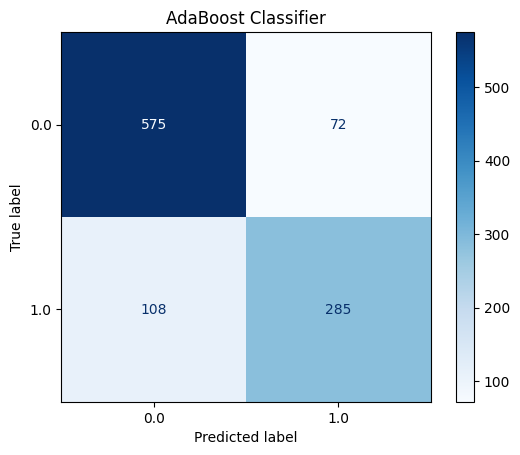

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    ada_pred,
    cmap="Blues"
)

plt.title("AdaBoost Classifier")
plt.show()

## ROC Curve

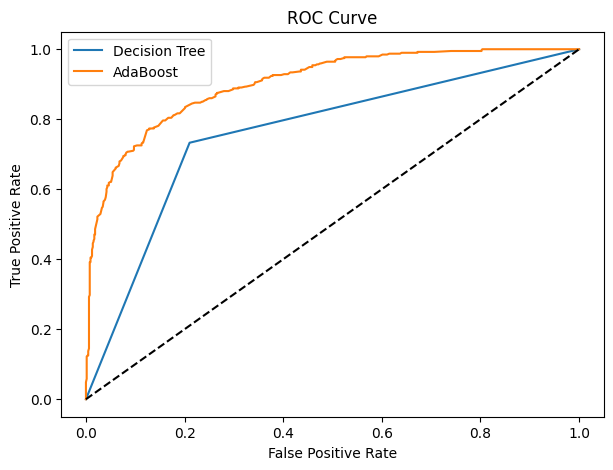

In [13]:
dt_fpr,dt_tpr,_=roc_curve(y_test,dt_prob)

ada_fpr,ada_tpr,_=roc_curve(y_test,ada_prob)

plt.figure(figsize=(7,5))

plt.plot(dt_fpr,dt_tpr,label="Decision Tree")

plt.plot(ada_fpr,ada_tpr,label="AdaBoost")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Classification Comparison

In [14]:
classification_results=pd.DataFrame({

"Model":["Decision Tree","AdaBoost"],
"Accuracy":[dt_accuracy,ada_accuracy],
"Precision":[dt_precision,ada_precision],
"Recall":[dt_recall,ada_recall],
"F1 Score":[dt_f1,ada_f1],
"ROC AUC":[dt_auc,ada_auc]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Decision Tree,0.768269,0.679245,0.732824,0.705018,0.761312
1,AdaBoost,0.826923,0.798319,0.725191,0.760000,0.903335


# REGRESSION

## Features and Target

In [15]:
X=df.drop(["final_score"],axis=1)

y=df["final_score"]

## Train Test Split

In [16]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.20,
random_state=42
)

## Decision Tree Regressor

In [17]:
dtr=DecisionTreeRegressor(random_state=42)

dtr.fit(X_train,y_train)

dt_pred=dtr.predict(X_test)

## Evaluation

In [18]:
dt_mae=mean_absolute_error(y_test,dt_pred)
dt_rmse=np.sqrt(mean_squared_error(y_test,dt_pred))
dt_r2=r2_score(y_test,dt_pred)

print("MAE:",dt_mae)
print("RMSE:",dt_rmse)
print("R2:",dt_r2)

MAE: 9.234615384615385
RMSE: 11.773122094251542
R2: 0.2581528173374218


## AdaBoost Regressor

In [19]:
ada_reg=AdaBoostRegressor(

    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

ada_reg.fit(X_train,y_train)

ada_pred=ada_reg.predict(X_test)

## Evaluation

In [20]:
ada_mae=mean_absolute_error(y_test,ada_pred)
ada_rmse=np.sqrt(mean_squared_error(y_test,ada_pred))
ada_r2=r2_score(y_test,ada_pred)

print("MAE:",ada_mae)
print("RMSE:",ada_rmse)
print("R2:",ada_r2)

MAE: 7.0004184358256945
RMSE: 8.619274651086652
R2: 0.6023759952637491


## Actual vs Predicted

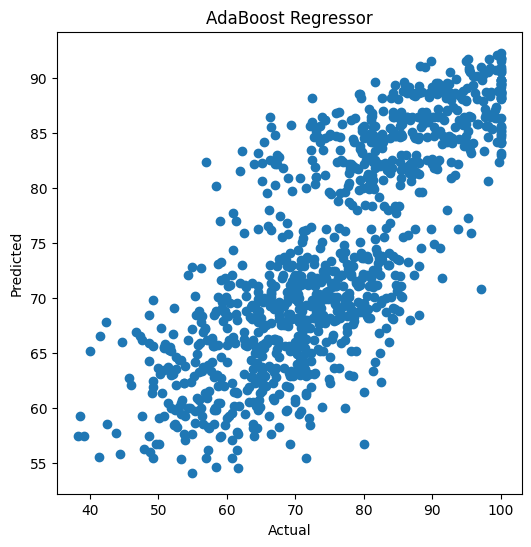

In [21]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,ada_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("AdaBoost Regressor")
plt.show()

## Regression Comparison

In [22]:
regression_results=pd.DataFrame({

"Model":["Decision Tree","AdaBoost"],
"MAE":[dt_mae,ada_mae],
"RMSE":[dt_rmse,ada_rmse],
"R2 Score":[dt_r2,ada_r2]

})

regression_results

,Model,MAE,RMSE,R2 Score
0,Decision Tree,9.234615,11.773122,0.258153
1,AdaBoost,7.000418,8.619275,0.602376


## Final Comparison

In [24]:
print("Classification Results")
print(classification_results)

print()

print("Regression Results")
print(regression_results)

Classification Results
           Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Decision Tree  0.768269   0.679245  0.732824  0.705018  0.761312
1       AdaBoost  0.826923   0.798319  0.725191  0.760000  0.903335

Regression Results
           Model       MAE       RMSE  R2 Score
0  Decision Tree  9.234615  11.773122  0.258153
1       AdaBoost  7.000418   8.619275  0.602376


# Conclusion
## AdaBoost Classifier
* AdaBoost builds many weak Decision Tree learners sequentially.
* Each new learner focuses on correcting the mistakes made by the previous learners.
* This sequential learning process generally improves Accuracy, Precision, Recall, F1-Score, and ROC-AUC compared to a single Decision Tree.
## AdaBoost Regressor
* AdaBoost Regressor sequentially improves prediction by emphasizing samples with larger prediction errors.
* It typically achieves a lower MAE and RMSE and a higher R² score than a single Decision Tree Regressor, making it a stronger model for predicting students' final scores.